## Geometry Overview

The coil (torus, major radius 5 mm) and permanent magnet (bar, 6×1×1 mm), as modeled in Maxwell 3D:

![Coil and magnet geometry](Images/Week1_ex1_result_image.png)

# Week1_ex1_analysis - Torque Value Verification

This notebook checks the torque value from `Week1_ex1.ipynb` (the Maxwell 3D magnetostatic simulation with the coil and permanent magnet) against a hand calculation. Nothing here needs an AEDT session — it's just plain Python/NumPy.

**Simulated result** (from AEDT: Results → Magnetostatic Report → Data Table, in `Week1_ex1.ipynb`):

$$\tau_{sim} = 28.287219\ \mu N\cdot m \quad (\theta = 45^\circ,\ I = 100\ A)$$

To check if this number actually makes sense, I tried two different hand calculations, going from a rough estimate to something a bit more careful.

## Approach 1 — Point-dipole approximation

Here I treated the coil (major radius R = 5 mm, I = 100 A) as an ideal circular loop, and just used the field at the center of the loop as if it were the same everywhere the magnet sits:

$$B_{center} = \frac{\mu_0 I}{2R}, \qquad \tau \approx (M \cdot V) \cdot B_{center} \cdot \sin\theta$$

For the magnetization M, I used the coercivity value from `get_magnetic_coercivity()` in `Week1_ex1.ipynb` (Hc = 890,000 A/m), assuming a roughly linear demagnetization curve — a fairly common simplification for hard permanent magnets.

**Result: 47.45 μN·m → 67.7% error compared to the simulation.**

## Approach 2 — Biot-Savart integration along the magnet length

The magnet is 6 mm long, which is basically the same size as the coil's radius (5 mm), so assuming a uniform field across the whole magnet in Approach 1 is a pretty rough assumption. To do better, I calculated the coil's field (using the Biot-Savart law, breaking the tilted loop into small segments) at several points along the magnet, then integrated the local torque contribution:

$$\tau_z = M \cdot A_{cross} \int_{-L/2}^{L/2} B_y(x)\, dx$$

(full calculation is in the code cell below)

**Result: 40.74 μN·m → 44.0% error compared to the simulation.**

## Interpretation

Just refining the theory a bit (accounting for how the field actually varies along the magnet) cut the error almost in half, from 67.7% down to 44.0%, without touching the simulation at all. That tells me the leftover gap probably isn't coming from a mistake in the FEM solve — it's more likely coming from things I'm still simplifying in the hand calculation:

- the coil is modeled as an infinitely thin wire, when it actually has a 0.5 mm radius (about 10% of the loop's major radius, so not really negligible)
- M ≈ Hc is only an approximation — it doesn't fully capture NdFe35's actual demagnetization curve

So I don't think refining the mesh or geometry in AEDT further would close this gap by much. The remaining error seems to be mostly on the analytical side, not the FEM solve. I'm treating this as good enough evidence that the simulated torque value is physically reasonable.

In [1]:
## Independent verification: theoretical torque estimate ##
## This cell reproduces the hand-calculation described above and does not require an AEDT session ##

import numpy as np

mu0 = 4 * np.pi * 1e-7          # vacuum permeability, T*m/A
I = 100.0                       # coil current, A
R = 5e-3                        # coil major radius, m
Hc = 890000.0                   # magnet coercivity, A/m (approximates magnetization M)
Lx, Ly, Lz = 6e-3, 1e-3, 1e-3    # magnet dimensions, m
A_cross = Ly * Lz                # magnet cross-sectional area, m^2
theta_tilt = np.radians(45)      # relative angle between coil axis and magnet, deg
sim_torque = 28.287219           # AEDT simulated torque, uN*m (from ex1.ipynb)

# --- Approach 1: point-dipole approximation ---
B_center = mu0 * I / (2 * R)
m_moment = Hc * (Lx * Ly * Lz)
torque_point_dipole = m_moment * B_center * np.sin(theta_tilt)

# --- Approach 2: Biot-Savart integration over the tilted coil, sampled along the magnet length ---
N = 2000
phi = np.linspace(0, 2*np.pi, N, endpoint=False)
s, c = np.sin(theta_tilt), np.cos(theta_tilt)
# Coil loop points after a 45-degree rotation about the Z axis
px = -R * np.cos(phi) * s
py =  R * np.cos(phi) * c
pz =  R * np.sin(phi)
points = np.stack([px, py, pz], axis=1)
dl = np.roll(points, -1, axis=0) - points
mid = (points + np.roll(points, -1, axis=0)) / 2

def biot_savart_B(target):
    r_vec = target - mid
    r_norm = np.linalg.norm(r_vec, axis=1)
    r_hat = r_vec / r_norm[:, None]
    dB = (mu0 * I / (4*np.pi)) * np.cross(dl, r_hat) / (r_norm[:, None]**2)
    return dB.sum(axis=0)

xs = np.linspace(-Lx/2, Lx/2, 61)
By = np.array([biot_savart_B(np.array([x, 0, 0]))[1] for x in xs])

def trapz(y, x):
    # Manual trapezoidal rule (avoids numpy-version-dependent trapz/trapezoid naming)
    return np.sum((y[1:] + y[:-1]) / 2 * (x[1:] - x[:-1]))

torque_integrated = Hc * A_cross * trapz(By, xs)

print(f"Approach 1 (point-dipole)         : {torque_point_dipole*1e6:.3f} uN*m  |  error = {abs(torque_point_dipole*1e6-sim_torque)/sim_torque*100:.1f}%")
print(f"Approach 2 (Biot-Savart integrated): {torque_integrated*1e6:.3f} uN*m  |  error = {abs(torque_integrated*1e6-sim_torque)/sim_torque*100:.1f}%")
print(f"AEDT simulation                   : {sim_torque:.3f} uN*m")

Approach 1 (point-dipole)         : 47.450 uN*m  |  error = 67.7%
Approach 2 (Biot-Savart integrated): 40.736 uN*m  |  error = 44.0%
AEDT simulation                   : 28.287 uN*m


## Visual Summary

Here are the two charts to make the comparison above a bit easier to see at a glance.

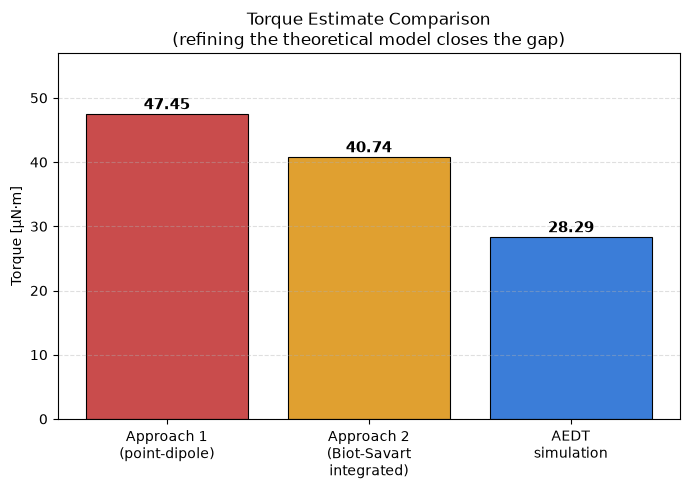

In [2]:
## Plot 1: torque estimate comparison across the three methods ##

import matplotlib.pyplot as plt

labels = ['Approach 1\n(point-dipole)', 'Approach 2\n(Biot-Savart\nintegrated)', 'AEDT\nsimulation']
values = [torque_point_dipole*1e6, torque_integrated*1e6, sim_torque]
colors = ['#c94c4c', '#e0a030', '#3b7dd8']

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.8, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Torque [μN·m]')
ax.set_title('Torque Estimate Comparison\n(refining the theoretical model closes the gap)')
ax.set_ylim(0, max(values)*1.2)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

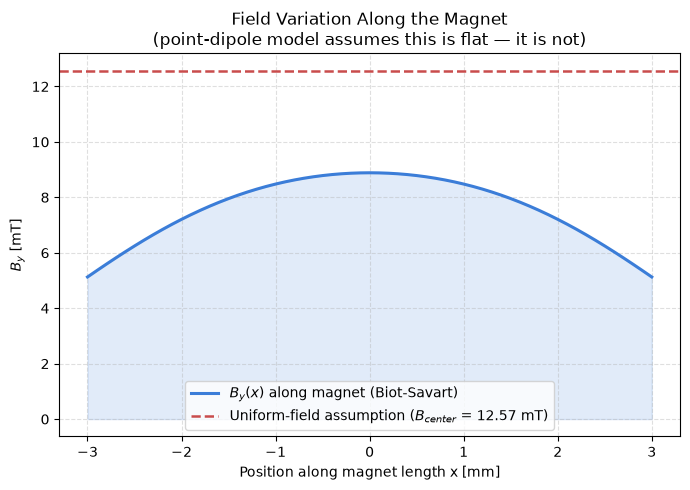

In [3]:
## Plot 2: field variation along the magnet length (why the uniform-field assumption breaks down) ##

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(xs*1000, By*1000, color='#3b7dd8', linewidth=2.2, label='$B_y(x)$ along magnet (Biot-Savart)')
ax.axhline(B_center*1000, color='#c94c4c', linestyle='--', linewidth=1.8,
           label=f'Uniform-field assumption ($B_{{center}}$ = {B_center*1000:.2f} mT)')
ax.fill_between(xs*1000, By*1000, alpha=0.15, color='#3b7dd8')
ax.set_xlabel('Position along magnet length x [mm]')
ax.set_ylabel('$B_y$ [mT]')
ax.set_title('Field Variation Along the Magnet\n(point-dipole model assumes this is flat — it is not)')
ax.legend(loc='lower center')
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()